# 03. EDA·다중공선성·가설검정

## 검정할 가설

- H₀: 미혼 집단과 미혼 외 집단의 평균 교육 수준은 같다.
- H₁: 두 집단의 평균 교육 수준은 다르다.
- 유의수준: α=0.05

모든 EDA와 가설검정은 Train 데이터에서만 수행합니다.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('adult-marriage-education-analysis 프로젝트 루트에서 실행하세요.')
sys.path.insert(0, str(project_root))
project_root

PosixPath('/Users/beeyaaa/Workspace/SK-SKALA/day15_data/adult-marriage-education-analysis')

In [2]:
import pandas as pd
from IPython.display import Image, display
from src.analysis import build_group_statistics, calculate_vif, run_hypothesis_test, split_data
from src.config import NUMERIC_MODEL_FEATURES, TARGET
from src.data import add_target, load_pandas, resolve_raw_path
from src.visualization import (
    create_education_hypothesis_chart, create_interactive_education_rate, create_multicollinearity_chart
)

prepared_df = add_target(load_pandas(resolve_raw_path(project_root)))
train_df, test_df = split_data(prepared_df)
print('Train:', train_df.shape)
print('Test:', test_df.shape)
print('Train 미혼 외 비율:', f"{train_df[TARGET].mean():.2%}")
print('Test 미혼 외 비율:', f"{test_df[TARGET].mean():.2%}")

Train: (26048, 16)
Test: (6513, 16)
Train 미혼 외 비율: 67.19%
Test 미혼 외 비율: 67.19%


## 1. 집단별 교육 수준 기술통계

In [3]:
group_statistics = build_group_statistics(train_df)
group_statistics.to_csv(project_root / 'reports' / 'tables' / 'education_group_statistics.csv', index=False)
group_statistics.round(3)

,ever_married,count,mean,std,var,median,min,max
0,0,8546,9.978,2.384,5.681,10.0,1,16
1,1,17502,10.141,2.652,7.036,10.0,1,16


## 2. 집단별 교육 수준 정적 시각화

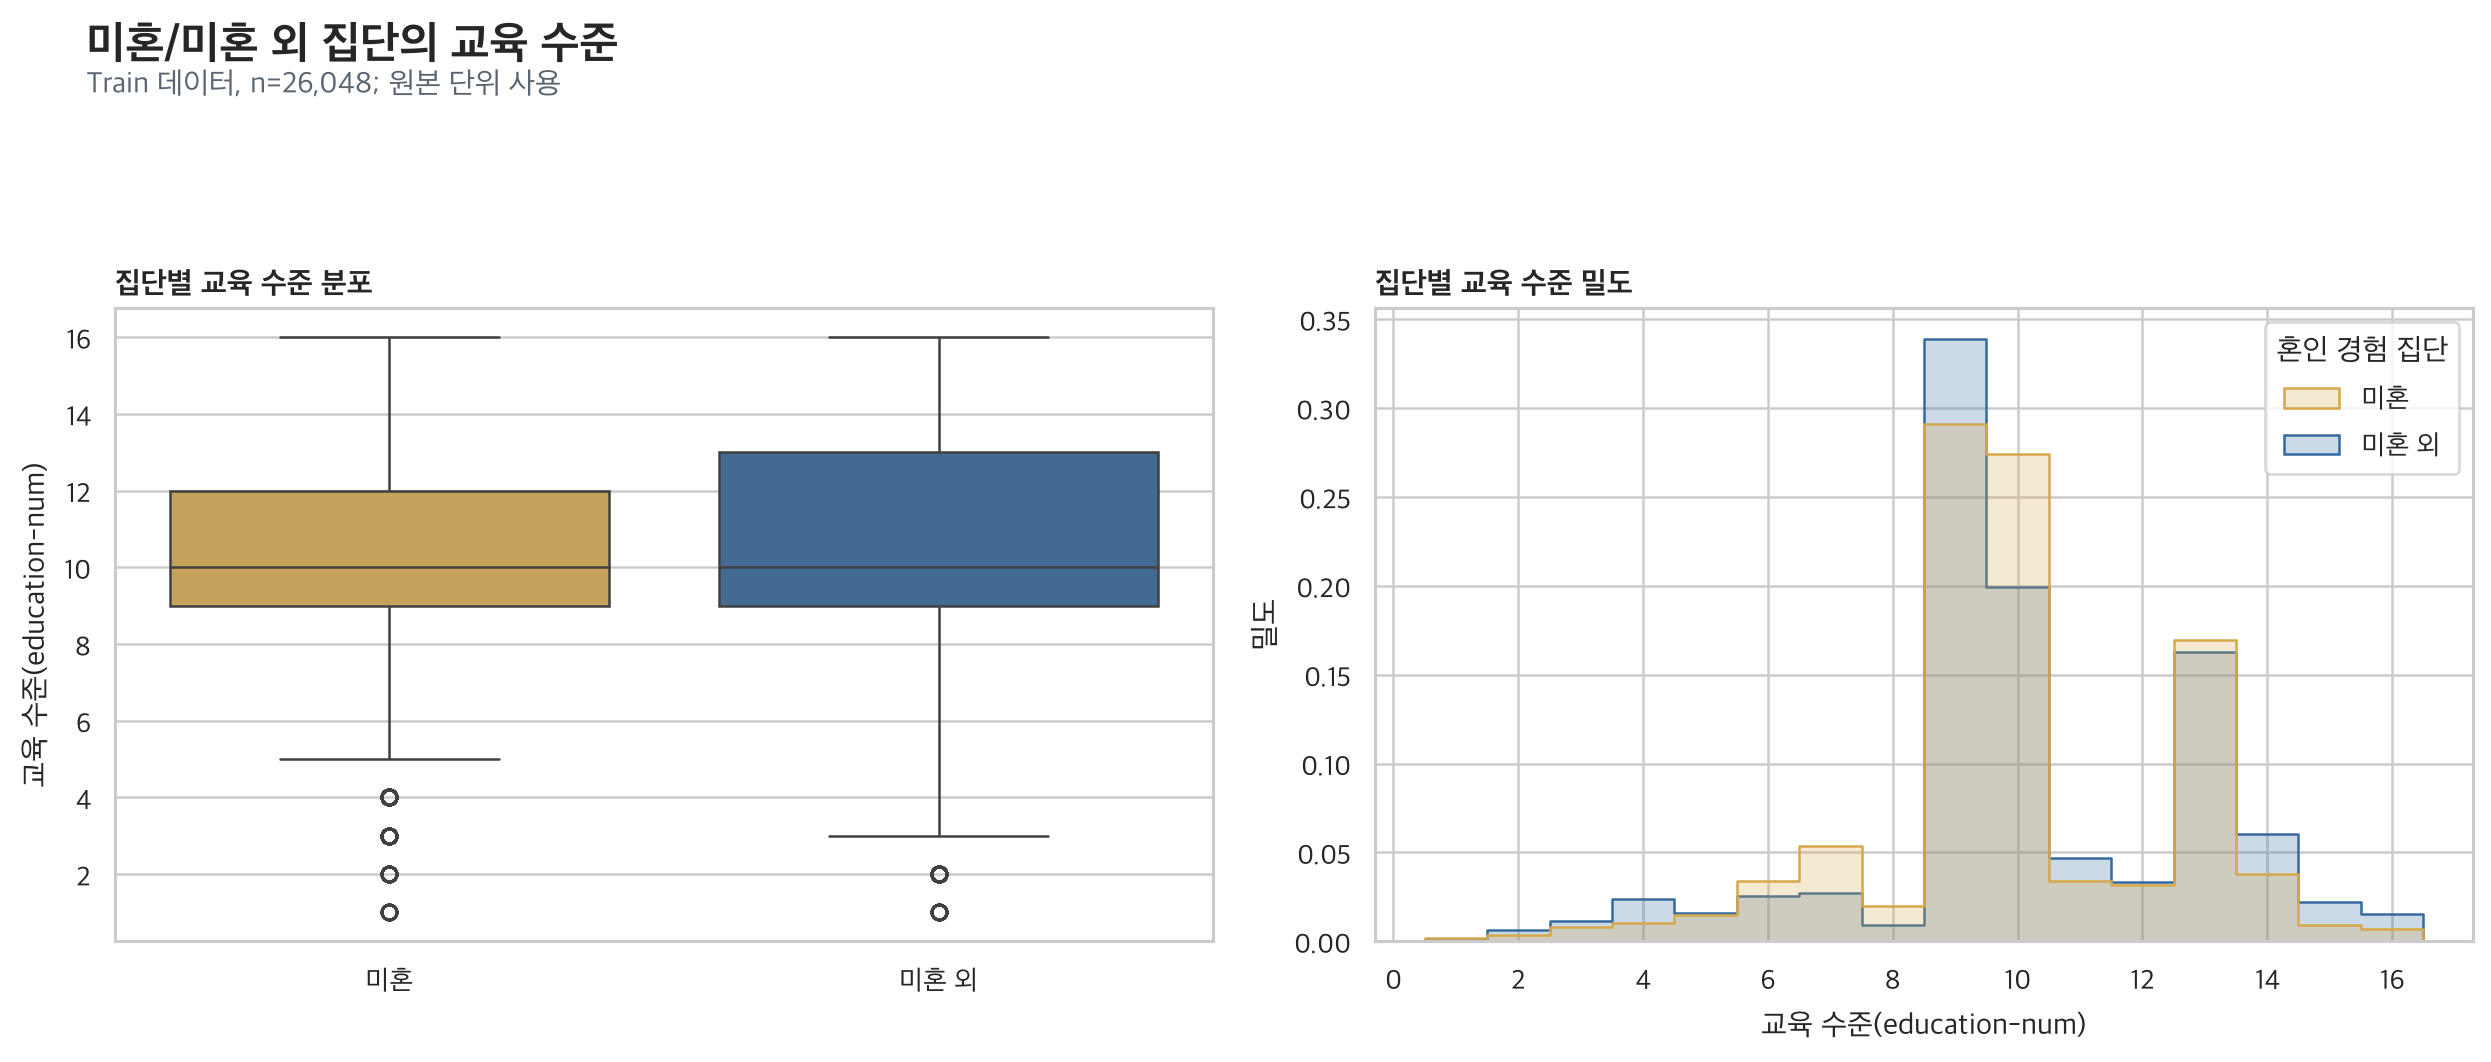

In [4]:
education_chart_path = create_education_hypothesis_chart(
    train_df, project_root / 'reports' / 'figures' / '03_education_by_marriage.png'
)
display(Image(filename=str(education_chart_path)))

![미혼/미혼 외 집단의 교육 수준](../reports/figures/03_education_by_marriage.png)

## 3. 숫자형 상관관계와 VIF

In [5]:
numeric_correlation = train_df[NUMERIC_MODEL_FEATURES].corr()
vif_table = calculate_vif(train_df)
display(numeric_correlation.round(3))
display(vif_table.round(3))

,age,education-num,hours-per-week,capital-gain,capital-loss
age,1.000,0.035,0.068,0.076,0.057
education-num,0.035,1.000,0.146,0.120,0.079
hours-per-week,0.068,0.146,1.000,0.077,0.054
capital-gain,0.076,0.120,0.077,1.000,-0.032
capital-loss,0.057,0.079,0.054,-0.032,1.000


,변수,VIF
0,education-num,1.041
1,hours-per-week,1.031
2,capital-gain,1.026
3,capital-loss,1.013
4,age,1.013


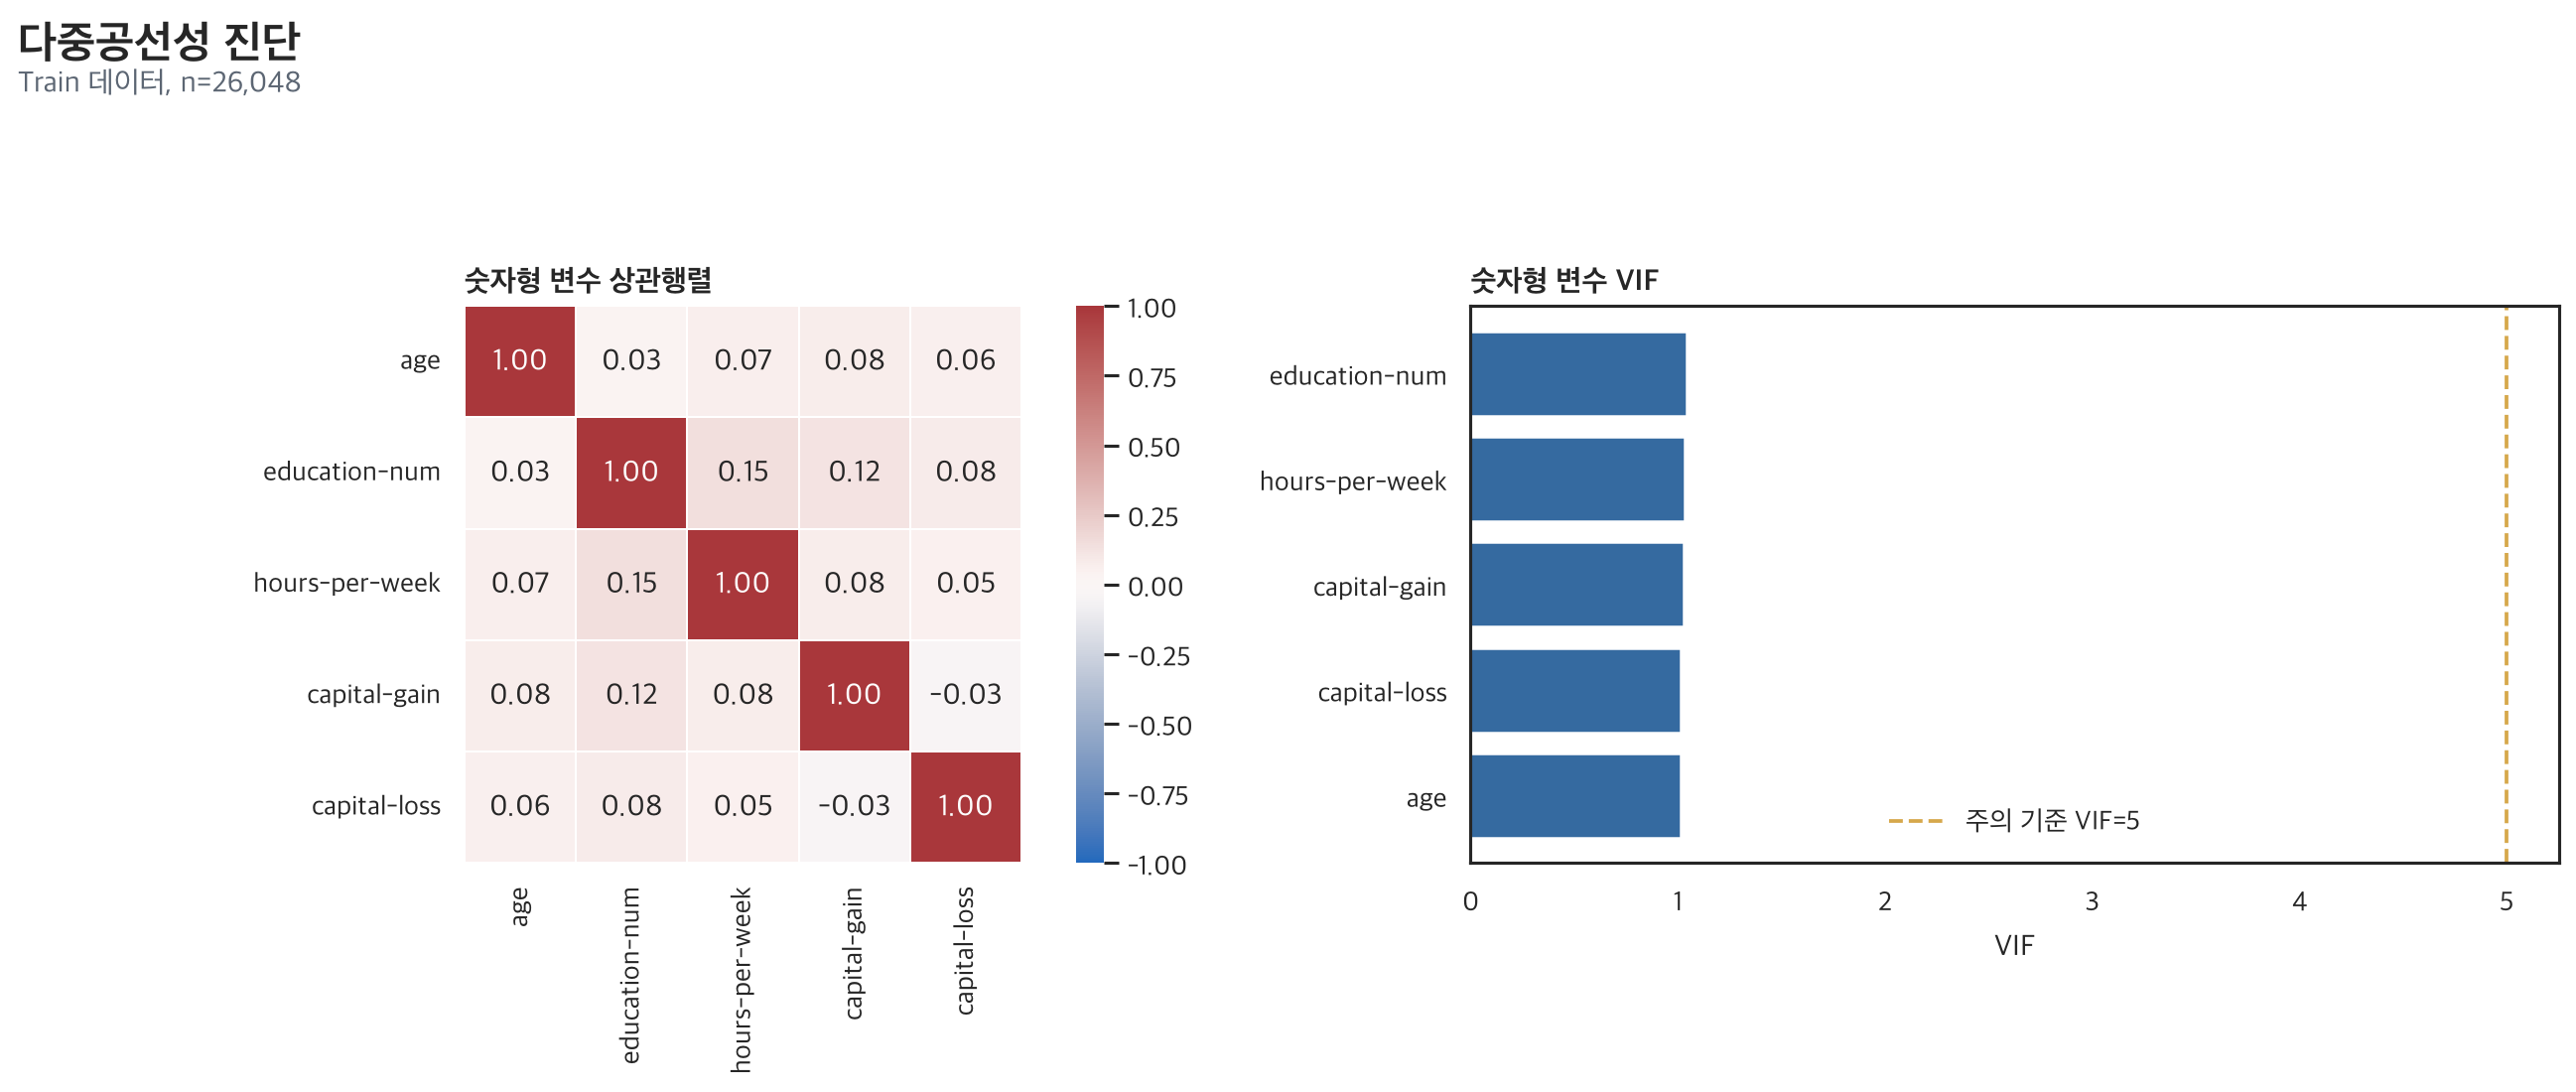

In [6]:
multicollinearity_chart_path = create_multicollinearity_chart(
    train_df, vif_table, project_root / 'reports' / 'figures' / '03_multicollinearity.png'
)
display(Image(filename=str(multicollinearity_chart_path)))

![숫자형 변수의 다중공선성 진단](../reports/figures/03_multicollinearity.png)

## 4. Welch t-test와 효과크기

두 집단의 분산이 같다고 가정하지 않는 Welch t-test를 사용합니다. p-value와 함께 Cohen’s d를 확인합니다.

In [7]:
hypothesis_result = run_hypothesis_test(train_df)
hypothesis_result.to_csv(project_root / 'reports' / 'tables' / 'hypothesis_result.csv', index=False)
hypothesis_result.round(6)

,미혼 외 집단 평균,미혼 집단 평균,평균 차이,Welch t 통계량,p-value,Point-biserial r,Cohen's d,판정
0,10.141355,9.977533,0.163822,5.015753,0.000001,0.029947,0.063809,H₀ 기각


In [8]:
row = hypothesis_result.iloc[0]
print(f"미혼 외 집단 평균: {row['미혼 외 집단 평균']:.3f}")
print(f"미혼 집단 평균: {row['미혼 집단 평균']:.3f}")
print(f"평균 차이: {row['평균 차이']:.3f}")
print(f"p-value: {row['p-value']:.3e}")
print(f"Cohen's d: {row["Cohen's d"]:.3f}")
print('판정:', row['판정'])
print('주의: 이는 집단 간 연관성이지 교육 수준의 인과효과가 아닙니다.')

미혼 외 집단 평균: 10.141
미혼 집단 평균: 9.978
평균 차이: 0.164
p-value: 5.331e-07
Cohen's d: 0.064
판정: H₀ 기각
주의: 이는 집단 간 연관성이지 교육 수준의 인과효과가 아닙니다.


## 5. Plotly 인터랙티브 차트 — 교육 수준별 미혼 외 비율

In [9]:
interactive_path = create_interactive_education_rate(
    train_df, project_root / 'reports' / 'interactive' / 'education_marriage_rate.html'
)
print('저장 위치:', interactive_path)

저장 위치: /Users/beeyaaa/Workspace/SK-SKALA/day15_data/adult-marriage-education-analysis/reports/interactive/education_marriage_rate.html


## 검증

In [10]:
assert len(train_df) == 26_048
assert len(test_df) == 6_513
assert set(train_df.index).isdisjoint(test_df.index)
assert education_chart_path.exists()
assert multicollinearity_chart_path.exists()
assert interactive_path.exists()
print('검증 완료: EDA·다중공선성·가설검정 산출물이 정상입니다.')

검증 완료: EDA·다중공선성·가설검정 산출물이 정상입니다.
